# Exploratory Data Analysis: Resturant Location Recommendation System

## 1. Business Understanding
**Problem Statement:**

The restaurant industry experiences high failure rates, with many businesses closing within their first few years. This project aims to develop a machine learning model that can predict the potential success of a restaurant in a given location.

**Key Business Questions:**

- Which locations have the highest potential for restaurant success?
- How does nearby competition affect a restaurant’s performance?
- What role do customer trends (reviews, ratings over time) play in predicting success?
- Can we identify underserved areas with high demand but low competition?
- How can multiple factors (location, competition, trends) be combined to improve prediction accuracy?

**Business Objectives:**

- Develop a machine learning system that predicts restaurant success based on location and business features
- Incorporate spatial relationships and competition analysis into predictions
- Capture time-based trends in customer behavior to improve insights
- Provide a ranking or scoring system for potential restaurant locations
- Help stakeholders (entrepreneurs/investors) make data-driven location decisions

**Success Criteria:**
- Achieve strong model performance (e.g., high ROC-AUC, precision, and recall)
- Demonstrate improved performance over models using only basic features (ratings/reviews)
- Ability to correctly identify high-potential vs low-potential locations
- Clear and interpretable success scores or rankings for locations

## 2. Data Understanding

The dataset consists of Yelp business data, including:

- Business attributes (category, location, price range)
- Customer reviews and ratings
- Operational status (is_open)
- Geographic and competitive information

The dataset was very large because it is a publicly available dataset that is continuously updated, so we selected a sample of 20,000 records for analysis.

### 2.1 Data dictionary

| Column Name      | Data Type          | Description                                           |
| ---------------- | ------------------ | ----------------------------------------------------- |
| `review_id`      | Object (string)    | Unique identifier for each review                     |
| `user_id`        | Object (string)    | Unique identifier for the user who wrote the review   |
| `business_id`    | Object (string)    | Unique identifier for the restaurant/business         |
| `review_stars`   | Float              | Rating given by the user (e.g., 1–5 stars)            |
| `useful`         | Integer            | Number of users who marked the review as useful       |
| `funny`          | Integer            | Number of users who marked the review as funny        |
| `cool`           | Integer            | Number of users who marked the review as cool         |
| `text`           | Object (string)    | Full text of the review                               |
| `date`           | Object (string)    | Date the review was posted                            |
| `name`           | Object (string)    | Name of the restaurant/business                       |
| `address`        | Object (string)    | Street address of the business                        |
| `city`           | Object (string)    | City where the business is located                    |
| `state`          | Object (string)    | State abbreviation                                    |
| `postal_code`    | Object (string)    | ZIP/postal code                                       |
| `latitude`       | Float              | Geographic latitude of the business                   |
| `longitude`      | Float              | Geographic longitude of the business                  |
| `business_stars` | Float              | Average rating of the business                        |
| `review_count`   | Integer            | Total number of reviews for the business              |
| `is_open`        | Integer (0/1)      | Whether the business is open (1 = open, 0 = closed)   |
| `attributes`     | Object (JSON-like) | Business features (e.g., OutdoorSeating, GoodForKids) |
| `categories`     | Object (string)    | Business categories (e.g., Restaurants, Pizza)        |
| `hours`          | Object (JSON-like) | Business operating hours                              |


### 2.2 Dataset Sizes

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import ast
import re
from sklearn.neighbors import BallTree
from sklearn.cluster import KMeans


In [29]:
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/MyDrive/Data Mining/Project/restaurants_dataset.csv'

df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
print("Restaurant Shape:", df.shape)
df.head()

Restaurant Shape: (20000, 22)


,review_id,user_id,business_id,review_stars,useful,funny,cool,text,date,name,...,state,postal_code,latitude,longitude,business_stars,review_count,is_open,attributes,categories,hours
0,7BXtAgGXenuDJgngFRecyA,vr-Rw3nMKIgGrVNT6A7p9g,Ipkx4Sa7ybn8C6LtTqTztw,4.0,3,0,1,"Here is the deal, in the morning, as early as ...",2016-03-08 20:11:17,Double Knot,...,PA,19107,39.949699,-75.162185,4.5,1140,1,"{'GoodForDancing': 'False', 'Caters': 'True', ...","Nightlife, Sushi Bars, Cafes, Japanese, Bars, ...","{'Monday': '16:0-22:0', 'Tuesday': '16:0-22:0'..."
1,0UFCKBCNlLyHvZoHRDAAqw,3l4I__FvMFrYKUrPQhvGwQ,cNua7EAP7aoHTEp734VqWA,5.0,0,0,0,Excellent resteraunt. Food was very good and c...,2019-01-27 19:23:37,Hên Vietnamese Eatery,...,NJ,08003,39.896071,-74.949167,4.5,192,1,"{'BusinessAcceptsCreditCards': 'True', 'NoiseL...","Vietnamese, Soup, Sandwiches, Restaurants","{'Monday': '0:0-0:0', 'Tuesday': '11:30-20:0',..."
2,K4wVCHTOSC3f28zI_CI2kw,1s_M2Q5NYOpOt_nqn_Pcmw,LLSCjPWE0iBKogY301vsKw,3.0,1,0,0,The service was fantastic. Very homey place. ...,2015-11-07 02:44:51,Gourmet Seafood & Grill,...,PA,19473,40.227668,-75.404260,3.5,16,0,"{'WiFi': ""u'free'"", 'BusinessAcceptsCreditCard...","Food, Bakeries, Mediterranean, Restaurants, Se...","{'Monday': '16:0-23:0', 'Tuesday': '12:0-1:0',..."
3,9jfXG0Mr2YaLmYK162je7Q,hZE4LEa_wb1J2ErAPYN0uQ,Ps7Q7BOKzJO4nDTUhbk43Q,5.0,0,0,0,"Fabulous seafood, creative menu, indoor and ou...",2019-04-23 22:33:19,Clear Sky Cafe,...,FL,33767,27.981960,-82.827297,4.5,1824,1,"{'OutdoorSeating': 'True', 'Alcohol': ""u'full_...","Restaurants, American (Traditional), Tapas/Sma...","{'Monday': '7:0-23:0', 'Tuesday': '7:0-23:0', ..."
4,wukrbOHww7F5RZgCI5t_Gg,2BolkZ_JvR-1NZ0ro-qE4w,qtg5d6UmDVFeUw5ZKVBl4Q,3.0,0,0,0,Really friendly staff! Very attentive. Food wa...,2016-08-15 00:57:41,Coffee House Too,...,PA,19125,39.976728,-75.123718,4.5,246,1,"{'NoiseLevel': ""u'average'"", 'Ambience': ""{'ro...","Food, Coffee & Tea, Restaurants, Breakfast & B...","{'Monday': '0:0-0:0', 'Tuesday': '7:0-14:0', '..."


## 3. Data Preparation

### 3.1 Data Inspection

3.1.1 Check missing values

In [31]:
# Missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)


Missing values:
 review_id           0
user_id             0
business_id         0
review_stars        0
useful              0
funny               0
cool                0
text                0
date                0
name                0
address            42
city                0
state               0
postal_code         3
latitude            0
longitude           0
business_stars      0
review_count        0
is_open             0
attributes         23
categories          0
hours             707
dtype: int64


3.1.2 Check duplicate values

In [32]:
business_duplicates = df['business_id'].duplicated().sum()
print("Duplicate Businesses:", business_duplicates)

user_duplicates = df['user_id'].duplicated().sum()
print("Duplicate Users:", user_duplicates)

review_duplicates = df['review_id'].duplicated().sum()
print("Duplicate Reviews:", review_duplicates)

Duplicate Businesses: 8054
Duplicate Users: 1104
Duplicate Reviews: 0


**Key Observation:**

- Most features contain no missing values
  - Minor missing values in:
    - postal_code (3 missing)
    - address (42)
    - attributes (23 missing)
    - hours (707 missing)
- Duplicate Businesses: 8054 usually means the same business_id appears many times because a business has many reviews.
- Duplicate Users: 1104 means the same user_id appears many times because a user reviewed multiple restaurants.
- There are no duplicate reviews

- Mixed data types:
  - Structured (ratings, counts)
  - Unstructured (text)
  - Semi-structured (attributes, hours)

### 3.2 Data Cleaning

3.2.1 Standardized Column Names

In [33]:
df.columns = df.columns.str.strip().str.lower()
print("Standardized column names:",df.columns)


Standardized column names: Index(['review_id', 'user_id', 'business_id', 'review_stars', 'useful',
       'funny', 'cool', 'text', 'date', 'name', 'address', 'city', 'state',
       'postal_code', 'latitude', 'longitude', 'business_stars',
       'review_count', 'is_open', 'attributes', 'categories', 'hours'],
      dtype='object')


3.2.2 Handling Missing Data

In [34]:
df["address"] = df["address"].fillna("Unknown")
df["postal_code"] = df["postal_code"].fillna("Unknown")


df["attributes"] = df["attributes"].fillna("{}")
df["hours"] = df["hours"].fillna("{}")

print("\nMissing values after cleaning:\n")
print(df.isnull().sum())

df.head()


Missing values after cleaning:

review_id         0
user_id           0
business_id       0
review_stars      0
useful            0
funny             0
cool              0
text              0
date              0
name              0
address           0
city              0
state             0
postal_code       0
latitude          0
longitude         0
business_stars    0
review_count      0
is_open           0
attributes        0
categories        0
hours             0
dtype: int64


,review_id,user_id,business_id,review_stars,useful,funny,cool,text,date,name,...,state,postal_code,latitude,longitude,business_stars,review_count,is_open,attributes,categories,hours
0,7BXtAgGXenuDJgngFRecyA,vr-Rw3nMKIgGrVNT6A7p9g,Ipkx4Sa7ybn8C6LtTqTztw,4.0,3,0,1,"Here is the deal, in the morning, as early as ...",2016-03-08 20:11:17,Double Knot,...,PA,19107,39.949699,-75.162185,4.5,1140,1,"{'GoodForDancing': 'False', 'Caters': 'True', ...","Nightlife, Sushi Bars, Cafes, Japanese, Bars, ...","{'Monday': '16:0-22:0', 'Tuesday': '16:0-22:0'..."
1,0UFCKBCNlLyHvZoHRDAAqw,3l4I__FvMFrYKUrPQhvGwQ,cNua7EAP7aoHTEp734VqWA,5.0,0,0,0,Excellent resteraunt. Food was very good and c...,2019-01-27 19:23:37,Hên Vietnamese Eatery,...,NJ,08003,39.896071,-74.949167,4.5,192,1,"{'BusinessAcceptsCreditCards': 'True', 'NoiseL...","Vietnamese, Soup, Sandwiches, Restaurants","{'Monday': '0:0-0:0', 'Tuesday': '11:30-20:0',..."
2,K4wVCHTOSC3f28zI_CI2kw,1s_M2Q5NYOpOt_nqn_Pcmw,LLSCjPWE0iBKogY301vsKw,3.0,1,0,0,The service was fantastic. Very homey place. ...,2015-11-07 02:44:51,Gourmet Seafood & Grill,...,PA,19473,40.227668,-75.404260,3.5,16,0,"{'WiFi': ""u'free'"", 'BusinessAcceptsCreditCard...","Food, Bakeries, Mediterranean, Restaurants, Se...","{'Monday': '16:0-23:0', 'Tuesday': '12:0-1:0',..."
3,9jfXG0Mr2YaLmYK162je7Q,hZE4LEa_wb1J2ErAPYN0uQ,Ps7Q7BOKzJO4nDTUhbk43Q,5.0,0,0,0,"Fabulous seafood, creative menu, indoor and ou...",2019-04-23 22:33:19,Clear Sky Cafe,...,FL,33767,27.981960,-82.827297,4.5,1824,1,"{'OutdoorSeating': 'True', 'Alcohol': ""u'full_...","Restaurants, American (Traditional), Tapas/Sma...","{'Monday': '7:0-23:0', 'Tuesday': '7:0-23:0', ..."
4,wukrbOHww7F5RZgCI5t_Gg,2BolkZ_JvR-1NZ0ro-qE4w,qtg5d6UmDVFeUw5ZKVBl4Q,3.0,0,0,0,Really friendly staff! Very attentive. Food wa...,2016-08-15 00:57:41,Coffee House Too,...,PA,19125,39.976728,-75.123718,4.5,246,1,"{'NoiseLevel': ""u'average'"", 'Ambience': ""{'ro...","Food, Coffee & Tea, Restaurants, Breakfast & B...","{'Monday': '0:0-0:0', 'Tuesday': '7:0-14:0', '..."


3.2.3 Clean Category

In [35]:
def clean_category_list(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return [str(i).strip().lower() for i in x]

    if isinstance(x, str):
        x = x.strip()


        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return [str(i).strip().lower() for i in parsed]
        except:
            pass


        return [i.strip().lower() for i in x.split(",") if i.strip()]

    return []

df["category_list"] = df["categories"].apply(clean_category_list)

3.2.4 Clean attribute column

In [36]:
def clean_value(x):
    if pd.isna(x):
        return None

    if isinstance(x, (dict, bool, int, float)):
        return x

    x = str(x).strip()

    x = re.sub(r"\bu'", "'", x)
    x = re.sub(r'\bu"', '"', x)

    if x == "True":
        return True
    if x == "False":
        return False
    if x == "None":
        return None

    if (x.startswith("'") and x.endswith("'")) or (x.startswith('"') and x.endswith('"')):
        x = x[1:-1]

    return x


def safe_literal_eval(x):
    try:
        return ast.literal_eval(x)
    except:
        return x


def parse_maybe_dict(x):
    x = clean_value(x)

    if isinstance(x, dict):
        return x

    if not isinstance(x, str):
        return x

    if x.startswith("{") and x.endswith("}"):
        x = re.sub(r"\bu'", "'", x)
        x = re.sub(r'\bu"', '"', x)
        return safe_literal_eval(x)

    return x


def parse_attributes(attr):
    if pd.isna(attr):
        return {}

    if isinstance(attr, dict):
        raw = attr
    else:
        text = str(attr).strip()
        text = re.sub(r"\bu'", "'", text)
        text = re.sub(r'\bu"', '"', text)

        raw = safe_literal_eval(text)
        if not isinstance(raw, dict):
            return {}

    cleaned = {}
    for k, v in raw.items():
        v = parse_maybe_dict(v)

        if isinstance(v, dict):
            cleaned[k] = {subk: clean_value(subv) for subk, subv in v.items()}
        else:
            cleaned[k] = clean_value(v)

    return cleaned


def flatten_dict(d, parent_key=""):
    items = {}
    for k, v in d.items():
        new_key = f"{parent_key}_{k}" if parent_key else k
        if isinstance(v, dict):
            items.update(flatten_dict(v, new_key))
        else:
            items[new_key] = v
    return items



parsed = df["attributes"].apply(parse_attributes)
flat = parsed.apply(flatten_dict)
attrs_df = pd.json_normalize(flat)

df = pd.concat([df.drop(columns=["attributes"]), attrs_df], axis=1)


def to_binary(x):
    if x is True:
        return 1
    if x is False:
        return 0
    return np.nan

for col in df.columns:
    if df[col].dropna().isin([True, False]).all():
        df[col] = df[col].map({True: 1, False: 0})

3.2.5 Clean Hour Column

In [37]:
def parse_hours(x):
    if pd.isna(x) or x == "{}":
        return {}

    try:
        return ast.literal_eval(x)
    except:
        return {}

df["hours_parsed"] = df["hours"].apply(parse_hours)

def time_to_float(t):
    try:
        h, m = t.split(":")
        return int(h) + int(m)/60
    except:
        return None


def calculate_hours(day_range):
    if not isinstance(day_range, str) or "-" not in day_range:
        return 0

    start, end = day_range.split("-")
    start = time_to_float(start)
    end = time_to_float(end)

    if start is None or end is None:
        return 0

    # handle overnight (e.g., 18:00 - 2:00)
    if end < start:
        return (24 - start) + end
    else:
        return end - start

### 3.3 Target Variable

In [38]:
df["success_score"] = df["business_stars"] * np.log1p(df["review_count"])

threshold = df["success_score"].quantile(0.70)
df["target"] = (df["success_score"] >= threshold).astype(int)

### 3.4 Feature Engineering

3.4.1 Hour-Based Features

In [39]:
def extract_features(hours_dict):
    if pd.isna(hours_dict) or hours_dict in ["", "None", "null"]:
        return pd.Series({
            "hours_open_per_week": 0,
            "days_open": 0,
            "avg_hours_per_day": 0,
            "open_late": 0,
            "open_early": 0
        })

    if isinstance(hours_dict, str):
        try:
            hours_dict = ast.literal_eval(hours_dict)
        except:
            return pd.Series({
                "hours_open_per_week": 0,
                "days_open": 0,
                "avg_hours_per_day": 0,
                "open_late": 0,
                "open_early": 0
            })

    if not isinstance(hours_dict, dict):
        return pd.Series({
            "hours_open_per_week": 0,
            "days_open": 0,
            "avg_hours_per_day": 0,
            "open_late": 0,
            "open_early": 0
        })

    total_hours = 0
    days_open = 0
    late_flag = 0
    early_flag = 0

    for day, time_range in hours_dict.items():
        hours = calculate_hours(time_range)

        if hours > 0:
            days_open += 1
            total_hours += hours

        if isinstance(time_range, str) and "-" in time_range:
            start, end = time_range.split("-")
            start_time = time_to_float(start)
            end_time = time_to_float(end)

            if end_time is not None and (end_time >= 22 or end_time <= 3):
                late_flag = 1

            if start_time is not None and start_time <= 9:
                early_flag = 1

    avg_hours = total_hours / days_open if days_open > 0 else 0

    return pd.Series({
        "hours_open_per_week": total_hours,
        "days_open": days_open,
        "avg_hours_per_day": avg_hours,
        "open_late": late_flag,
        "open_early": early_flag
    })

features = df["hours_parsed"].apply(extract_features)
df = pd.concat([df, features], axis=1)

In [40]:
def weekend_hours(hours_dict):
    if not isinstance(hours_dict, dict):
        return 0

    weekend_days = ["Saturday", "Sunday"]
    total = 0

    for d in weekend_days:
        if d in hours_dict:
            total += calculate_hours(hours_dict[d])

    return total

df["weekend_hours"] = df["hours_parsed"].apply(weekend_hours)

In [41]:
df["is_always_open"] = (df["hours_open_per_week"] > 100).astype(int)

3.4.2 Business-based Features

In [42]:
df["num_categories"] = df["category_list"].apply(len)

df["has_nightlife"] = df["category_list"].apply(
    lambda x: int(any(cat in x for cat in ["nightlife", "bars", "cocktail bars", "pubs", "lounges"]))
)

df["has_fast_food"] = df["category_list"].apply(
    lambda x: int(any(cat in x for cat in ["fast food", "burgers", "sandwiches", "pizza"]))
)

df["has_breakfast"] = df["category_list"].apply(
    lambda x: int("breakfast & brunch" in x)
)

df["has_seafood"] = df["category_list"].apply(
    lambda x: int("seafood" in x)
)

df["has_asian"] = df["category_list"].apply(
    lambda x: int(any(cat in x for cat in [
        "japanese", "chinese", "thai", "vietnamese", "korean", "sushi bars", "asian fusion"
    ]))
)

df["has_mexican"] = df["category_list"].apply(
    lambda x: int(any(cat in x for cat in ["mexican", "tacos", "tex-mex"]))
)

df["has_italian"] = df["category_list"].apply(
    lambda x: int(any(cat in x for cat in ["italian", "pizza"]))
)

ignore_categories = {
    "restaurants", "food", "nightlife", "bars",
    "event planning & services", "caterers"
}

def get_primary_category(cat_list):
    for cat in cat_list:
        if cat not in ignore_categories:
            return cat
    return "unknown"

df["primary_category"] = df["category_list"].apply(get_primary_category)


In [43]:
if "RestaurantsPriceRange2" in df.columns:
    df["RestaurantsPriceRange2"] = pd.to_numeric(df["RestaurantsPriceRange2"], errors="coerce")

if "NoiseLevel" in df.columns:
    df["NoiseLevel"] = df["NoiseLevel"].map({
        "quiet": 1,
        "average": 2,
        "loud": 3,
        "very_loud": 4
    })

if "Alcohol" in df.columns:
    df["Alcohol"] = df["Alcohol"].replace({
        "none": "none",
        "beer_and_wine": "beer_wine",
        "full_bar": "full_bar"
    })

if "WiFi" in df.columns:
    df["WiFi"] = df["WiFi"].replace({
        "free": "free",
        "paid": "paid",
        "no": "no"
    })

if "RestaurantsAttire" in df.columns:
    df["RestaurantsAttire"] = df["RestaurantsAttire"].replace({
        "casual": "casual",
        "dressy": "dressy",
        "formal": "formal"
    })

In [44]:
def safe_col(col):
    return df[col].fillna(0) if col in df.columns else 0

df["is_full_service"] = (
    (safe_col("RestaurantsTableService") + safe_col("RestaurantsReservations")) >= 1
).astype(int)

df["is_bar_style"] = (
    ((df.get("Alcohol") == "full_bar").astype(int) if "Alcohol" in df else 0)
    + safe_col("HappyHour")
    + safe_col("HasTV")
    >= 2
).astype(int)

df["is_family_friendly"] = (
    (safe_col("GoodForKids") + safe_col("RestaurantsGoodForGroups")) >= 2
).astype(int)

df["is_takeout_friendly"] = (
    (safe_col("RestaurantsTakeOut") + safe_col("RestaurantsDelivery")) >= 1
).astype(int)

df["is_date_spot"] = (
    (
        safe_col("Ambience_romantic")
        + safe_col("Ambience_intimate")
        + safe_col("RestaurantsReservations")
    ) >= 2
).astype(int)

def count_true(prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        return pd.Series(0, index=df.index)
    return df[cols].fillna(0).sum(axis=1)

df["parking_options_count"] = count_true("BusinessParking_")
df["meal_options_count"] = count_true("GoodForMeal_")
df["ambience_score"] = count_true("Ambience_")
df["music_options_count"] = count_true("Music_")
df["best_nights_count"] = count_true("BestNights_")

3.4.3 Location-based features

In [45]:
df = df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)

coords_rad = np.radians(df[["latitude", "longitude"]].values)
earth_radius_km = 6371.0

k_neighbors = min(6, len(df))

tree = BallTree(coords_rad, metric="haversine")
distances, indices = tree.query(coords_rad, k=k_neighbors)

distances_km = distances * earth_radius_km

df["nearest_dist"] = distances_km[:, 1] if k_neighbors > 1 else 0

In [46]:
radius_km = 1.0
radius_rad = radius_km / earth_radius_km

neighbors_within_1km = tree.query_radius(coords_rad, r=radius_rad)

df["num_neighbors_1km"] = [max(len(nbrs) - 1, 0) for nbrs in neighbors_within_1km]

In [47]:
same_cuisine_counts = []

for i in range(len(df)):
    my_cuisine = df.at[i, "primary_category"]

    if k_neighbors > 1:
        neighbor_idxs = indices[i, 1:]
        neighbor_cuisines = df.iloc[neighbor_idxs]["primary_category"].values
        count_same = np.sum(neighbor_cuisines == my_cuisine)
    else:
        count_same = 0

    same_cuisine_counts.append(int(count_same))

df["same_cuisine_neighbors"] = same_cuisine_counts

In [48]:
avg_neighbor_rating = []

for i in range(len(df)):
    if k_neighbors > 1:
        neighbor_idxs = indices[i, 1:]
        avg_rating = df.iloc[neighbor_idxs]["business_stars"].mean()
    else:
        avg_rating = np.nan

    avg_neighbor_rating.append(avg_rating)

df["avg_neighbor_rating"] = avg_neighbor_rating

In [49]:
n_clusters = min(30, len(df))

if n_clusters > 1:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df["location_cluster"] = kmeans.fit_predict(df[["latitude", "longitude"]])
else:
    df["location_cluster"] = 0


3.5.3  Final Model Dataset

In [51]:
feature_columns = [
  "name",
  "city",
  "state",
  "target",
  "is_open",
  "postal_code",
  "latitude",
  "longitude",
  "business_stars",
  "RestaurantsPriceRange2",
  "NoiseLevel",
  "parking_options_count",
  "meal_options_count",
  "ambience_score",
  "music_options_count",
  "best_nights_count",
  "is_full_service",
  "is_bar_style",
  "is_family_friendly",
  "is_takeout_friendly",
  "is_date_spot",
  "primary_category",
  "hours_open_per_week",
  "days_open",
  "avg_hours_per_day",
  "open_late",
  "open_early",
  "weekend_hours",
  "nearest_dist",
  "num_neighbors_1km",
  "same_cuisine_neighbors",
  "avg_neighbor_rating",
  "location_cluster",
  "num_categories",
  "has_nightlife",
  "has_fast_food",
  "has_breakfast",
  "has_seafood",
  "has_asian",
  "has_mexican",
  "has_italian"
]

X = df[feature_columns]
y = df["target"]

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (20000, 41)
Target distribution:
 target
0    13991
1     6009
Name: count, dtype: int64


In [ ]:
model_df = X.copy()
model_df["target"] = y

# -------------------------------
# Save to CSV
# -------------------------------
model_df.to_csv("model_dataset.csv", index=False)

print("✅ model_dataset.csv saved successfully!")
print("Shape:", model_df.shape)

In [53]:
df = model_df.copy()

### 3.6 Feature Selection

3.6.1 Visualizations

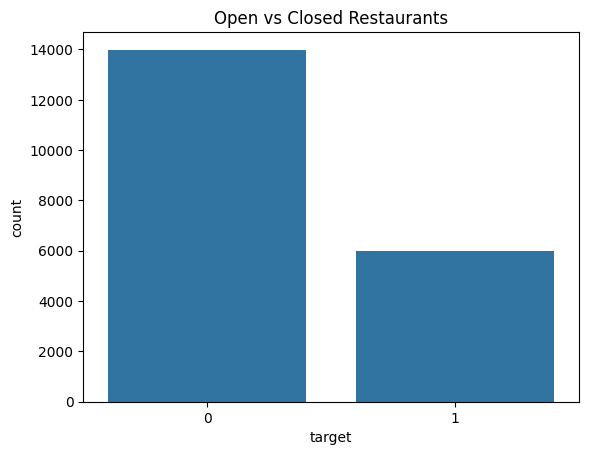

In [54]:
sns.countplot(x="target", data=df)
plt.title("Open vs Closed Restaurants")
plt.show()

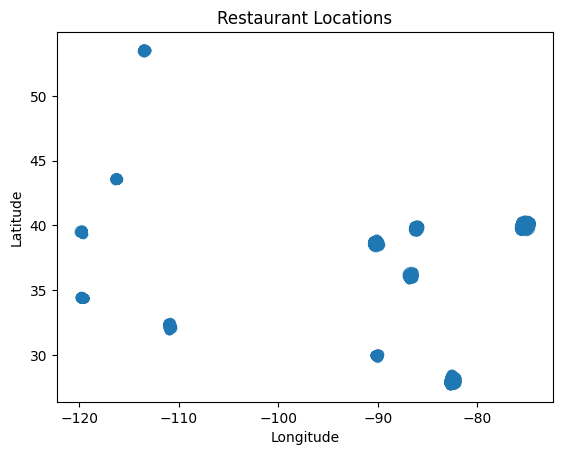

In [55]:
plt.scatter(df["longitude"], df["latitude"], alpha=0.3)
plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

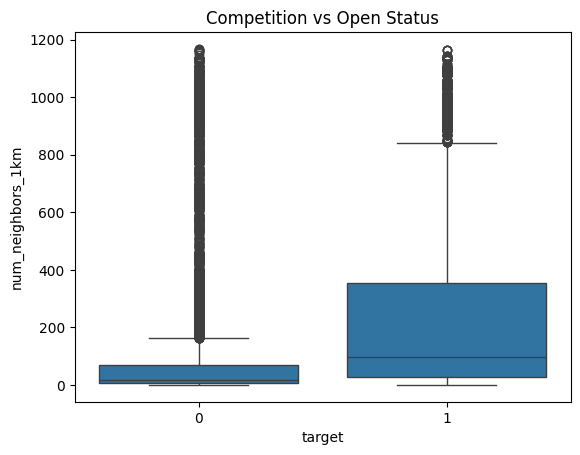

In [56]:
sns.boxplot(x="target", y="num_neighbors_1km", data=df)
plt.title("Competition vs Open Status")
plt.show()

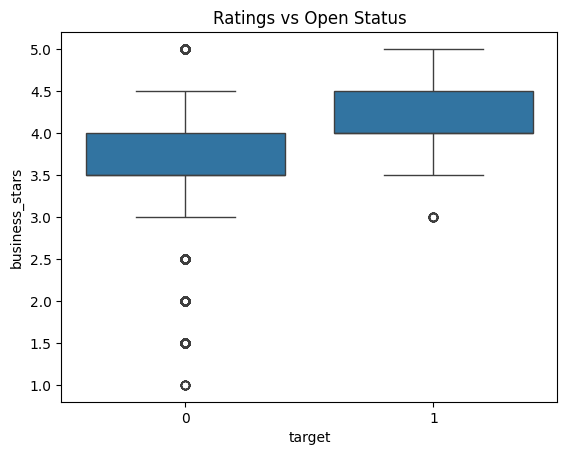

In [57]:
sns.boxplot(x="target", y="business_stars", data=df)
plt.title("Ratings vs Open Status")
plt.show()

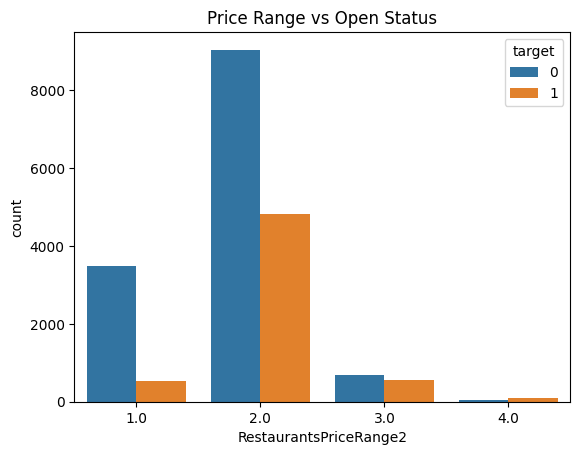

In [58]:
sns.countplot(x="RestaurantsPriceRange2", hue="target", data=df)
plt.title("Price Range vs Open Status")
plt.show()

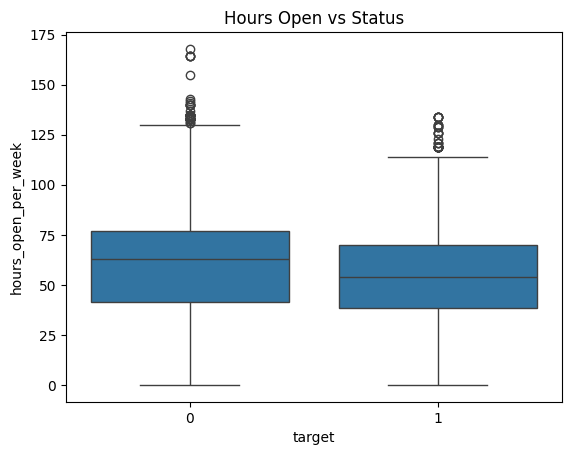

In [59]:
sns.boxplot(x="target", y="hours_open_per_week", data=df)
plt.title("Hours Open vs Status")
plt.show()

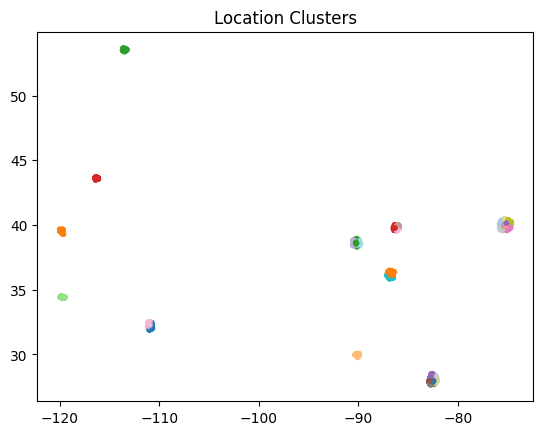

In [60]:
plt.scatter(df["longitude"], df["latitude"], c=df["location_cluster"], cmap="tab20", s=10)
plt.title("Location Clusters")
plt.show()

3.6.2 Key Insights

**1. Target Distribution**: The dataset is imbalanced, so evaluation metrics like F1-score and ROC-AUC are more appropriate than accuracy.

**2. Location Plot**: Restaurant locations are geographically clustered, indicating that location plays an important role in business outcomes and justifying the use of spatial features such as clustering and neighbor-based competition.

**3. Competition:** Competition, measured by the number of nearby restaurants, shows some separation between open and closed businesses, suggesting that competitive density influences survival, although the relationship is not strictly linear.

**4. Ratings vs Open Status:** Business ratings appear to have little impact on whether a restaurant remains open, as the distribution of ratings is nearly identical for both open and closed establishments.


**5. Price Range:** Price range shows a moderate relationship with business status, but it is not a strong standalone predictor and is likely more useful when combined with other features.


**6. Hours Open per Week:** Restaurants that remain open tend to have slightly higher weekly operating hours, suggesting that longer availability may contribute to business sustainability.

**7. Location Clusters:** Location-based clustering reveals clear regional groupings, reinforcing that geographic factors and local market conditions are important drivers of restaurant success.

3.6.3 Avoid Feature Leakage

To prevent data leakage, all preprocessing steps including scaling, clustering, and feature engineering were performed within a pipeline and fit only on the training data. Features that could incorporate future information were carefully reviewed to ensure they reflect only data available at prediction time.